# B1 – Axis 2 (supply side): where does DNSE still have room and efficiency to grow?

**Author:** Phong (Team B) · **Input:** `data/raw/FBAR2_TEAM B DATASET.xlsx` (collected by the team's BA, version 25/09/2026)

**What this notebook does:**
1. **Extract** only the *hard-typed* input cells (not formulas) from the Excel file into tidy tables in `data/clean/`.
2. **Clean** the data and log every issue (codes D01–D15; see `report/data_issues_log.md`).
3. **Validate** by re-computing every Excel formula in pandas and comparing with the values Excel stored.
4. **Compute axis-2 metrics** under the agreed definitions:
   - 2.1 momentum
   - 2.2 headroom
   - 2.3 efficiency
5. **Plot** Figures 8, 9 and 10.
6. **Score** Table 4 with quantitative rules (2.4 and 2.5 still missing) and run the sensitivity check (Table PL2).
7. **Generate** the report sentences and the source register.

**Conventions:**
- Money in **VND billion**.
- Ratios stored as decimals (0.25 = 25%).
- Share changes in **percentage points (pp)**.
- Run with *Restart & Run all*.

## 0. Setup

In [1]:
import warnings, re, datetime as dt
warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np
import pandas as pd
import openpyxl
import matplotlib.pyplot as plt

ROOT  = Path.cwd().parent if Path.cwd().name == "notebook" else Path.cwd()
RAW   = ROOT / "data/raw/FBAR2_TEAM B DATASET.xlsx"
CLEAN = ROOT / "data/clean"
FIG   = ROOT / "figures"
CLEAN.mkdir(parents=True, exist_ok=True)
FIG.mkdir(parents=True, exist_ok=True)

TICKERS = ["DSE", "SSI", "VND", "HCM", "VCI", "MBS"]
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)

wb_f = openpyxl.load_workbook(RAW)
wb_v = openpyxl.load_workbook(RAW, data_only=True)

def v(sheet, addr):
    return wb_v[sheet][addr].value

def f(sheet, addr):
    x = wb_f[sheet][addr].value
    return getattr(x, "text", x)

print("Sheets:", wb_v.sheetnames)

Sheets: ['2.1_NewInvestors', '2.1_Margin', '2.1_Derivatives', '2.1_Summary', '2.2_NewInvestors', '2.2_Margin', '2.2_Derivatives', '2.3_Brokerage', '2.3_Margin', '2.3_Derivatives']


## 1. Extract hard-typed inputs

Only cells the BA typed in directly are read. Every formula cell is **re-computed** in section 3 as a check, never copied.

The cleaning log starts here; every fix appends one row.

In [2]:
LOG = []
def log(code, sheet, cell, issue, action, before=None, after=None):
    LOG.append(dict(code=code, sheet=sheet, cell=cell, issue=issue,
                    action=action, before=before, after=after))

S = "2.1_NewInvestors"
acq_raw = pd.DataFrame([{
    "row": r,
    "period_label":      v(S, f"A{r}"),
    "report_date_raw":   v(S, f"B{r}"),
    "new_account_share": v(S, f"C{r}"),
    "source_report":     v(S, f"E{r}"),
} for r in range(2, 6)])

base_raw = pd.DataFrame([{
    "row": r,
    "ref_date_raw":  v(S, f"H{r}"),
    "accounts":      v(S, f"I{r}"),
    "qualifier":     v(S, f"J{r}"),
    "source_id_raw": v(S, f"L{r}"),
} for r in range(2, 6)])

S = "2.1_Margin"
mh = pd.DataFrame([{
    "row": r,
    "quarter":   v(S, f"A{r}"),
    "ticker":    v(S, f"B{r}"),
    "margin_bn": v(S, f"C{r}"),
    "source_id": v(S, f"F{r}"),
} for r in range(2, 26)])

S = "2.1_Derivatives"
ds = pd.DataFrame([{
    "row": r,
    "quarter":   v(S, f"A{r}"),
    "rank":      v(S, f"B{r}"),
    "broker":    v(S, f"C{r}"),
    "share":     v(S, f"D{r}"),
    "source_id": v(S, f"E{r}"),
} for r in range(2, 72)])

S = "2.2_Margin"
bs = pd.DataFrame([{
    "ticker":          v(S, f"A{r}"),
    "equity_q4_25":    v(S, f"C{r}"),
    "equity_q2_26":    v(S, f"E{r}"),
    "debt_q4_25":      v(S, f"Q{r}"),
    "debt_q2_26":      v(S, f"R{r}"),
    "cash_q2_26":      v(S, f"S{r}"),
    "int_exp_h1_26":   v(S, f"T{r}"),
    "bank_affiliated": v(S, f"Z{r}") == "Yes",
} for r in range(2, 8)])

S = "2.3_Margin"
lend = pd.DataFrame([{
    "ticker":               v(S, f"A{r}"),
    "lending_q4_25":        v(S, f"E{r}"),
    "lending_q2_26":        v(S, f"H{r}"),
    "lending_income_h1_26": v(S, f"J{r}"),
    "other_borrow_cost_h1_26": v(S, f"O{r}"),
    "other_borrow_cost_formula": str(f(S, f"O{r}")),
} for r in range(2, 8)])

S = "2.3_Brokerage"
brk = pd.DataFrame([{
    "ticker":         v(S, f"A{r}"),
    "brk_rev_h1_25":  v(S, f"B{r}"),
    "brk_exp_h1_25":  v(S, f"C{r}"),
    "brk_rev_h1_26":  v(S, f"F{r}"),
    "brk_exp_h1_26":  v(S, f"G{r}"),
} for r in range(2, 8)])

S = "2.2_NewInvestors"
newinv = {v(S, f"A{r}"): v(S, f"B{r}") for r in range(2, 8)}

S = "2.2_Derivatives"
deriv_mkt = {v(S, f"A{r}"): v(S, f"B{r}") for r in range(10, 13)}

S = "2.3_Derivatives"
fee_raw = pd.DataFrame([{
    "row": r,
    "contracts_from": v(S, f"A{r}"),
    "contracts_to":   v(S, f"B{r}"),
    "fee_raw":        v(S, f"C{r}"),
} for r in range(2, 7)])
deriv_param = {
    "matched_contracts_h1_26": v(S, "G2"),
    "dse_share_h1_26":         v(S, "G3"),
    "side_factor":             v(S, "G4"),
    "annualisation":           v(S, "G5"),
}

print("Extracted:",
      f"{len(mh)} margin rows, {len(ds)} derivatives rows, {len(bs)} brokers' financials")

Extracted: 24 margin rows, 70 derivatives rows, 6 brokers' financials


## 2. Clean and log

Issue codes match `report/data_issues_log.md`.

In [3]:
def parse_date(x, sheet, cell):
    if isinstance(x, dt.datetime):
        fixed = pd.Timestamp(year=x.year, month=x.day, day=x.month)
        log("D04", sheet, cell, "Date parsed month-first, breaking chronological order",
            "Swap day and month back", x.date().isoformat(), fixed.date().isoformat())
        return fixed
    return pd.to_datetime(x, dayfirst=True)

acq = acq_raw.copy()
acq["report_date"] = [parse_date(x, "2.1_NewInvestors", f"B{r}")
                      for x, r in zip(acq.report_date_raw, acq.row)]
base = base_raw.copy()
base["ref_date"] = [parse_date(x, "2.1_NewInvestors", f"H{r}")
                    for x, r in zip(base.ref_date_raw, base.row)]
log("D05", "2.1_NewInvestors", "B2:B5,H2:H5", "Dates stored as text",
    "Parse with dayfirst=True", "text", "datetime")

acq["period_covered"] = acq.period_label.replace({"FY/2025": "FY2025"})
log("D06", "2.1_NewInvestors", "A5/E5", "Label says FY/2025 but period column says Q4/2025",
    "Treated as full-year 2025 (matches the Masterplan); column E renamed source_report",
    "Q4/2025", "FY2025")

ID_RE = re.compile(r"^[A-Z]+\d+(\.\d+)?$")
base["source_id"] = base.source_id_raw.where(base.source_id_raw.astype(str).str.match(ID_RE))
for r, raw in zip(base.row, base.source_id_raw):
    if not ID_RE.match(str(raw)):
        log("D07", "2.1_NewInvestors", f"L{r}", "Source_ID holds a reporting period",
            "Source ID left blank, pending BA", raw, None)

base["is_lower_bound"] = base.qualifier.eq(">")
base["is_approx"]      = base.qualifier.eq("~")
base = base.sort_values("ref_date").reset_index(drop=True)

mh["source_id"] = mh.groupby("quarter")["source_id"].ffill()
ds["source_id"] = ds.groupby("quarter")["source_id"].ffill()
ds["rank"] = ds["rank"].astype(int)

fee = fee_raw.copy()
fee["negotiable"] = fee.fee_raw.astype(str).str.contains("agreement")
fee["fee_vnd"] = fee.fee_raw.astype(str).str.extract(r"(\d+)")[0].astype(float)
fee["contracts_to"] = pd.to_numeric(fee.contracts_to, errors="coerce")
for r, raw in zip(fee.row, fee.fee_raw):
    if isinstance(raw, str):
        log("D11", "2.3_Derivatives", f"C{r}", "Text in a numeric column",
            "Use 300 and flag negotiable", raw.strip(), 300)
log("D12", "2.3_Derivatives", "F4", "Truncated label '[Asss'",
    "Renamed to side_factor [ASSUMPTION] = 2", v("2.3_Derivatives", "F4"), "side_factor [ASSUMPTION]")

m_q4 = mh[mh.quarter == "Q4/2025"].set_index("ticker").margin_bn
m_q2 = mh[mh.quarter == "Q2/2026"].set_index("ticker").margin_bn
adv = lend.set_index("ticker")[["lending_q4_25", "lending_q2_26"]].copy()
adv["advances_q4_25"] = adv.lending_q4_25 - m_q4
adv["advances_q2_26"] = adv.lending_q2_26 - m_q2
adv["margin_fig_is_total_lending_q4"] = adv.advances_q4_25.abs() < 1
adv["margin_fig_is_total_lending_q2"] = adv.advances_q2_26.abs() < 1
for t, row in adv.iterrows():
    flags = [q for q, fl in [("Q4/2025", row.margin_fig_is_total_lending_q4),
                             ("Q2/2026", row.margin_fig_is_total_lending_q2)] if fl]
    if flags:
        log("D01", "2.1_Margin / 2.3_Margin", t,
            f"Reported 'margin' {', '.join(flags)} is actually total loans (advances < 1 bn)",
            "Use total loans (2.3_Margin E/H) for all six brokers")
display(adv.round(2))

lend_xl = lend.copy()
LINE24_DSE_6M26     = 248_925_871_777 / 1e9
PROV_LOANS_DSE_6M26 = 8_964_451_724 / 1e9
DSE_BORROW_COST_LOANS_6M26 = LINE24_DSE_6M26 - PROV_LOANS_DSE_6M26
old = lend.loc[lend.ticker == "DSE", "other_borrow_cost_h1_26"].iloc[0]
lend.loc[lend.ticker == "DSE", "other_borrow_cost_h1_26"] = DSE_BORROW_COST_LOANS_6M26
log("D02", "2.3_Margin", "O2 (DSE)",
    "Hard-coded 240 bn borrowing cost; BA located the source (6M/2026 FS, code 24, note 29)",
    "Use exact value = 248.926 - 8.964 bn", round(old, 3), round(DSE_BORROW_COST_LOANS_6M26, 3))

log("D02b", "2.3_Margin", "O3:O7",
    "Peers may also book borrowing costs in code 24 but are set to 0",
    "Kept at 0; break-even computed in section 4.2; pending BA split of code 24")

,lending_q4_25,lending_q2_26,advances_q4_25,advances_q2_26,margin_fig_is_total_lending_q4,margin_fig_is_total_lending_q2
ticker,,,,,,
DSE,5832.2,6303.10,0.2,0.10,True,True
SSI,38940.1,40472.60,324.1,436.02,False,False
VND,14319.0,12859.04,672.0,196.04,False,False
HCM,28150.1,29023.50,0.1,-0.02,True,True
VCI,16167.2,17145.80,0.2,499.34,True,False
MBS,15040.6,16828.10,523.6,157.70,False,False


### 2.1 Save clean tables

In [4]:
tables = {
    "B_acquisition_share.csv": acq[["period_label", "period_covered", "report_date",
                                    "new_account_share", "source_report"]],
    "B_account_base.csv":      base[["ref_date", "accounts", "qualifier", "is_lower_bound",
                                     "is_approx", "source_id"]],
    "B_margin_reported_quarterly.csv": mh.drop(columns="row"),
    "B_derivatives_share_quarterly.csv": ds.drop(columns="row"),
    "B_balance_sheet.csv": bs,
    "B_lending.csv":       lend.drop(columns="other_borrow_cost_formula"),
    "B_brokerage.csv":     brk,
    "B_deriv_fee_schedule.csv": fee.drop(columns=["row", "fee_raw"]),
}
for name, df in tables.items():
    df.to_csv(CLEAN / name, index=False)
pd.Series(newinv, name="value").to_csv(CLEAN / "B_newinv_inputs.csv")
pd.Series({**deriv_mkt, **deriv_param}, name="value").to_csv(CLEAN / "B_deriv_inputs.csv")
print("Saved", len(tables) + 2, "files to", CLEAN)

Saved 10 files to /sessions/rcw-01j9p5bjh2qf52enqwypiwpk/mnt/FBA/Submission/data/clean


## 3. Validation: re-compute the Excel formulas

Metrics are re-computed **exactly as the BA's formulas do**, including definitions that section 4 later replaces, and compared with the stored Excel values.
- A match (tolerance ≤ 1e-6) means extraction is correct and the spreadsheet has no broken references.
- Any mismatch must be investigated.

In [5]:
checks = []
def check(name, sheet, cell, ours):
    xl = v(sheet, cell)
    ok = xl is not None and np.isclose(float(ours), float(xl), rtol=1e-6, atol=1e-6)
    checks.append(dict(metric=name, sheet=sheet, cell=cell, excel=xl, python=float(ours), match=ok))

mh["sample_total"] = mh.groupby("quarter").margin_bn.transform("sum")
for _, r in mh.iterrows():
    check(f"margin share {r.ticker} {r.quarter}", "2.1_Margin", f"E{r.row}", r.margin_bn / r.sample_total)

b = bs.set_index("ticker")
for i, t in enumerate(TICKERS, start=2):
    cap = 2 * b.at[t, "equity_q2_26"]
    check(f"utilisation {t}", "2.2_Margin", f"G{i}", m_q2[t] / cap)
    check(f"headroom {t}",    "2.2_Margin", f"H{i}", cap - m_q2[t])
    avg_debt = (b.at[t, "debt_q4_25"] + b.at[t, "debt_q2_26"]) / 2
    check(f"funding cost (interest only) {t}", "2.2_Margin", f"V{i}", b.at[t, "int_exp_h1_26"] * 2 / avg_debt)

L = lend_xl.set_index("ticker")
for i, t in enumerate(TICKERS, start=2):
    avg_lend = (L.at[t, "lending_q4_25"] + L.at[t, "lending_q2_26"]) / 2
    y = L.at[t, "lending_income_h1_26"] * 2 / avg_lend
    avg_debt = (b.at[t, "debt_q4_25"] + b.at[t, "debt_q2_26"]) / 2
    c = (b.at[t, "int_exp_h1_26"] + L.at[t, "other_borrow_cost_h1_26"]) * 2 / avg_debt
    check(f"lending yield {t}", "2.3_Margin", f"K{i}", y)
    check(f"blended funding cost {t}", "2.3_Margin", f"R{i}", c)
    check(f"net spread pp {t}", "2.3_Margin", f"S{i}", (y - c) * 100)

K = brk.set_index("ticker")
for i, t in enumerate(TICKERS, start=2):
    check(f"brk contribution margin H1/25 {t}", "2.3_Brokerage", f"E{i}",
          (K.at[t, "brk_rev_h1_25"] - K.at[t, "brk_exp_h1_25"]) / K.at[t, "brk_rev_h1_25"])
    check(f"brk contribution margin H1/26 {t}", "2.3_Brokerage", f"I{i}",
          (K.at[t, "brk_rev_h1_26"] - K.at[t, "brk_exp_h1_26"]) / K.at[t, "brk_rev_h1_26"])

dse_ds = ds[ds.broker == "DSE"].set_index("quarter").share
for i, q in enumerate(["Q4/2024", "Q1/2025", "Q2/2025", "Q3/2025", "Q4/2025", "Q1/2026", "Q2/2026"], start=2):
    check(f"DSE deriv share {q}", "2.1_Derivatives", f"O{i}", dse_ds[q])
p = deriv_param
sides_year = p["matched_contracts_h1_26"] * p["dse_share_h1_26"] * p["side_factor"] * p["annualisation"]
check("deriv revenue low fee (bn/yr)",  "2.3_Derivatives", "G10", sides_year * fee.fee_vnd.min() / 1e9)
check("deriv revenue high fee (bn/yr)", "2.3_Derivatives", "G11", sides_year * fee.fee_vnd.max() / 1e9)

val = pd.DataFrame(checks)
val.to_csv(CLEAN / "B_validation_vs_excel.csv", index=False)
print(f"Validation: {val.match.sum()}/{len(val)} metrics match Excel")
display(val[~val.match])

Validation: 81/81 metrics match Excel


,metric,sheet,cell,excel,python,match


## 4. Axis-2 metrics under the agreed definitions

Changes versus the Excel file:
- **D01:** lending = **total loans (margin loans + sale-proceeds advances)** for all six brokers.
- **D02:** funding cost **A** (main) = interest expense + borrowing cost of loans (income-statement code 24). For DSE this is VND 239.96 bn, sourced from the 6M/2026 financial statements. Funding cost **B** (sensitivity) = interest expense only. Peers' code-24 split is not yet available, so section 4.2 computes a **break-even**.
- **D03:** ceiling utilisation is reported at **both** Q4/2025 and Q2/2026, each using lending and equity at the same date.

### 4.1 Branch 2.2 – Margin headroom (Figure 9)

In [6]:
hd = bs.merge(lend, on="ticker")
rows = []
for q, lcol, ecol in [("Q4/2025", "lending_q4_25", "equity_q4_25"),
                      ("Q2/2026", "lending_q2_26", "equity_q2_26")]:
    t = hd[["ticker", "bank_affiliated", lcol, ecol]].rename(columns={lcol: "lending_bn", ecol: "equity_bn"})
    t["quarter"] = q
    rows.append(t)
    rows.append(pd.DataFrame([{"ticker": "SAMPLE", "bank_affiliated": False, "quarter": q,
                               "lending_bn": t.lending_bn.sum(), "equity_bn": t.equity_bn.sum()}]))
headroom = pd.concat(rows, ignore_index=True)
headroom["ceiling_bn"]  = 2 * headroom.equity_bn
headroom["utilisation"] = headroom.lending_bn / headroom.ceiling_bn
headroom["headroom_bn"] = headroom.ceiling_bn - headroom.lending_bn
headroom["headroom_vs_book"] = headroom.headroom_bn / headroom.lending_bn
headroom.to_csv(CLEAN / "2.2_headroom.csv", index=False)

H2 = headroom[headroom.quarter == "Q2/2026"].set_index("ticker")
H4 = headroom[headroom.quarter == "Q4/2025"].set_index("ticker")
display(headroom.pivot(index="ticker", columns="quarter", values=["utilisation", "headroom_bn"]).round(3))
print(f"DSE used {H4.at['DSE','utilisation']:.1%} of its ceiling at Q4/2025 and {H2.at['DSE','utilisation']:.1%} at Q2/2026; "
      f"headroom VND {H2.at['DSE','headroom_bn']:,.0f} bn (sample: {H2.at['SAMPLE','utilisation']:.1%}).")

utilisation         headroom_bn          
quarter     Q2/2026 Q4/2025     Q2/2026   Q4/2025
ticker                                           
DSE           0.579   0.678     4579.82   2772.46
HCM           0.991   0.968      256.08    936.18
MBS           0.705   0.941     7055.22    949.00
SAMPLE        0.556   0.612    97737.70  75164.96
SSI           0.511   0.627    38711.40  23167.90
VCI           0.500   0.449    17129.98  19852.60
VND           0.300   0.343    30005.20  27486.82

DSE used 67.8% of its ceiling at Q4/2025 and 57.9% at Q2/2026; headroom VND 4,580 bn (sample: 55.6%).


### 4.2 Branch 2.3 – Lending and brokerage efficiency (Figure 10), two funding-cost definitions

In [7]:
ef = bs.merge(lend, on="ticker")
ef["avg_lending_bn"] = (ef.lending_q4_25 + ef.lending_q2_26) / 2
ef["avg_debt_bn"]    = (ef.debt_q4_25 + ef.debt_q2_26) / 2
ef["lending_yield"]  = ef.lending_income_h1_26 * 2 / ef.avg_lending_bn
ef["funding_cost_A"] = (ef.int_exp_h1_26 + ef.other_borrow_cost_h1_26) * 2 / ef.avg_debt_bn
ef["funding_cost_B"] = ef.int_exp_h1_26 * 2 / ef.avg_debt_bn
ef["spread_A_pp"] = (ef.lending_yield - ef.funding_cost_A) * 100
ef["spread_B_pp"] = (ef.lending_yield - ef.funding_cost_B) * 100
ef["rank_spread_A"] = ef.spread_A_pp.rank(ascending=False).astype(int)
ef["rank_spread_B"] = ef.spread_B_pp.rank(ascending=False).astype(int)

bk = brk.copy()
bk["contrib_margin_h1_26"] = (bk.brk_rev_h1_26 - bk.brk_exp_h1_26) / bk.brk_rev_h1_26
bk["contrib_margin_h1_25"] = (bk.brk_rev_h1_25 - bk.brk_exp_h1_25) / bk.brk_rev_h1_25
bk["rank_contrib"] = bk.contrib_margin_h1_26.rank(ascending=False).astype(int)

eff = ef[["ticker", "bank_affiliated", "lending_yield", "funding_cost_A", "funding_cost_B",
          "spread_A_pp", "spread_B_pp", "rank_spread_A", "rank_spread_B"]].merge(
      bk[["ticker", "contrib_margin_h1_25", "contrib_margin_h1_26", "rank_contrib"]], on="ticker")
eff.to_csv(CLEAN / "2.3_efficiency.csv", index=False)
display(eff.round(4))

dse_spread = eff.set_index("ticker").at["DSE", "spread_A_pp"]
be = ef[ef.ticker != "DSE"][["ticker", "spread_A_pp", "avg_debt_bn"]].copy()
be["gap_to_dse_pp"] = be.spread_A_pp - dse_spread
be["breakeven_extra_cost_pp_of_debt"] = be.gap_to_dse_pp.clip(lower=0)
be["breakeven_line24_bn_h1"] = be.breakeven_extra_cost_pp_of_debt / 100 * be.avg_debt_bn / 2
be.to_csv(CLEAN / "2.3_peer_breakeven_line24.csv", index=False)
display(be.round(2))
print("A peer whose H1/2026 code-24 borrowing cost exceeds 'breakeven_line24_bn_h1' would rank below DSE.")

deriv_rev = {
    "rev_low_bn_per_year":  sides_year * fee.fee_vnd.min() / 1e9,
    "rev_high_bn_per_year": sides_year * fee.fee_vnd.max() / 1e9,
    "rev_per_1pp_low_bn":   p["matched_contracts_h1_26"] * p["side_factor"] * p["annualisation"] * 0.01 * fee.fee_vnd.min() / 1e9,
    "rev_per_1pp_high_bn":  p["matched_contracts_h1_26"] * p["side_factor"] * p["annualisation"] * 0.01 * fee.fee_vnd.max() / 1e9,
}
print({k: round(x, 2) for k, x in deriv_rev.items()})

,ticker,bank_affiliated,lending_yield,funding_cost_A,funding_cost_B,spread_A_pp,spread_B_pp,rank_spread_A,rank_spread_B,contrib_margin_h1_25,contrib_margin_h1_26,rank_contrib
0,DSE,False,0.1108,0.0629,0.0150,4.7895,9.5777,4,1,-0.1816,-0.1999,6
1,SSI,False,0.1079,0.0532,0.0532,5.4634,5.4634,2,3,0.2459,0.3394,2
2,VND,False,0.1145,0.0517,0.0517,6.2820,6.2820,1,2,0.3316,0.2995,3
3,HCM,False,0.1071,0.0724,0.0724,3.4718,3.4718,6,6,0.2319,0.2290,4
4,VCI,False,0.1054,0.0626,0.0626,4.2775,4.2775,5,5,0.2106,0.3828,1
5,MBS,True,0.1136,0.0634,0.0634,5.0141,5.0141,3,4,0.1398,0.1371,5


,ticker,spread_A_pp,avg_debt_bn,gap_to_dse_pp,breakeven_extra_cost_pp_of_debt,breakeven_line24_bn_h1
1,SSI,5.46,57099.38,0.67,0.67,192.38
2,VND,6.28,27052.06,1.49,1.49,201.88
3,HCM,3.47,28491.19,-1.32,0.00,0.00
4,VCI,4.28,18884.09,-0.51,0.00,0.00
5,MBS,5.01,18738.82,0.22,0.22,21.04


A peer whose H1/2026 code-24 borrowing cost exceeds 'breakeven_line24_bn_h1' would rank below DSE.
{'rev_low_bn_per_year': np.float64(8.78), 'rev_high_bn_per_year': np.float64(29.26), 'rev_per_1pp_low_bn': np.float64(0.34), 'rev_per_1pp_high_bn': np.float64(1.15)}


### 4.3 Branch 2.1 – Share momentum (Figure 8)

**Rule:** use the **latest 12 months with data** for all three segments. Other windows are used only in the sensitivity check.

In [8]:
mh_share = mh[mh.ticker == "DSE"].set_index("quarter").eval("margin_bn / sample_total")

lend_share = {
    "Q4/2025": L.at["DSE", "lending_q4_25"] / L.lending_q4_25.sum(),
    "Q2/2026": L.at["DSE", "lending_q2_26"] / L.lending_q2_26.sum(),
}
a = acq.set_index("period_label").new_account_share

def mrow(seg, window, metric, s, s_val, e, e_val, base):
    return dict(segment=seg, window=window, metric=metric, start=s, start_val=s_val,
                end=e, end_val=e_val, change_pp=(e_val - s_val) * 100, is_base=base)

mom_all = pd.DataFrame([
    mrow("New investors", "12M", "Share of new accounts", "Late-2024", a["Late-2024"], "FY2025", a["FY/2025"], True),
    mrow("New investors", "18M", "Share of new accounts", "H1/2024", a["H1/2024"], "FY2025", a["FY/2025"], False),
    mrow("Margin", "12M", "Share of sample lending (reported series)", "Q2/2025", mh_share["Q2/2025"], "Q2/2026", mh_share["Q2/2026"], True),
    mrow("Margin", "6M", "Share of sample lending (loans + advances)", "Q4/2025", lend_share["Q4/2025"], "Q2/2026", lend_share["Q2/2026"], False),
    mrow("Derivatives", "12M", "Derivatives brokerage share", "Q2/2025", dse_ds["Q2/2025"], "Q2/2026", dse_ds["Q2/2026"], True),
    mrow("Derivatives", "6M", "Derivatives brokerage share", "Q4/2025", dse_ds["Q4/2025"], "Q2/2026", dse_ds["Q2/2026"], False),
])
mom_all.to_csv(CLEAN / "2.1_momentum.csv", index=False)
momentum = mom_all[mom_all.is_base].reset_index(drop=True)
display(mom_all.round(4))

,segment,window,metric,start,start_val,end,end_val,change_pp,is_base
0,New investors,12M,Share of new accounts,Late-2024,0.2107,FY2025,0.2000,-1.070,True
1,New investors,18M,Share of new accounts,H1/2024,0.3000,FY2025,0.2000,-10.000,False
2,Margin,12M,Share of sample lending (reported series),Q2/2025,0.0523,Q2/2026,0.0519,-0.031,True
3,Margin,6M,Share of sample lending (loans + advances),Q4/2025,0.0492,Q2/2026,0.0514,0.216,False
4,Derivatives,12M,Derivatives brokerage share,Q2/2025,0.1762,Q2/2026,0.2538,7.760,True
5,Derivatives,6M,Derivatives brokerage share,Q4/2025,0.2426,Q2/2026,0.2538,1.120,False


## 5. Figures

- **Blue** = DSE; **grey** = peers; hatched = bank-affiliated.
- Each title is a conclusion sentence generated from the numbers.
- Sources are given in the footer.

In [9]:
ACCENT, PEER, INK, MUTED = "#2F6FD6", "#B8BEC7", "#1F2328", "#6B7280"
plt.rcParams.update({"font.size": 10, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.edgecolor": MUTED, "axes.labelcolor": INK, "xtick.color": MUTED,
                     "ytick.color": MUTED, "axes.grid": True, "grid.color": "#E5E7EB",
                     "grid.linewidth": 0.6, "axes.axisbelow": True})

def footer(fig, text):
    fig.text(0.01, 0.01, text, fontsize=7.5, color=MUTED, ha="left", va="bottom")

def bar_colors(tickers):
    return [ACCENT if t == "DSE" else PEER for t in tickers]

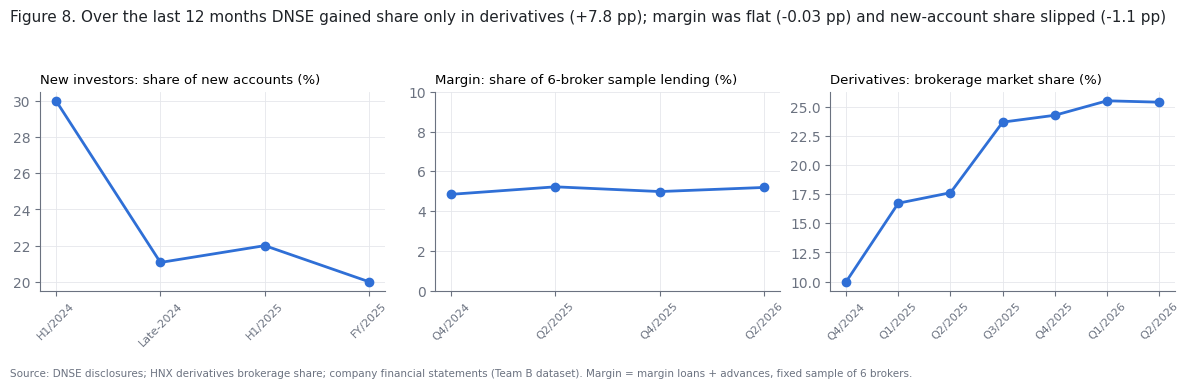

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), sharey=False)
a = acq.dropna(subset=["new_account_share"])
axes[0].plot(a.period_label, a.new_account_share * 100, marker="o", color=ACCENT, lw=2)
axes[0].set_title("New investors: share of new accounts (%)", fontsize=9.5, loc="left")
axes[1].plot(list(mh_share.index), mh_share.values * 100, marker="o", color=ACCENT, lw=2)
axes[1].set_title("Margin: share of 6-broker sample lending (%)", fontsize=9.5, loc="left")
axes[1].set_ylim(0, 10)
qs = list(dse_ds.index)
axes[2].plot(qs, dse_ds.values * 100, marker="o", color=ACCENT, lw=2)
axes[2].set_title("Derivatives: brokerage market share (%)", fontsize=9.5, loc="left")
for ax in axes:
    ax.tick_params(axis="x", rotation=45, labelsize=8)
dchg = momentum.set_index("segment").change_pp
fig.suptitle(f"Figure 8. Over the last 12 months DNSE gained share only in derivatives ({dchg['Derivatives']:+.1f} pp); "
             f"margin was flat ({dchg['Margin']:+.2f} pp) and new-account share slipped ({dchg['New investors']:+.1f} pp)",
             x=0.01, ha="left", fontsize=11, color=INK)
footer(fig, "Source: DNSE disclosures; HNX derivatives brokerage share; company financial statements (Team B dataset). "
            "Margin = margin loans + advances, fixed sample of 6 brokers.")
fig.tight_layout(rect=(0, 0.05, 1, 0.93))
fig.savefig(FIG / "Fig08_B_market_share.png", dpi=200)
plt.show()

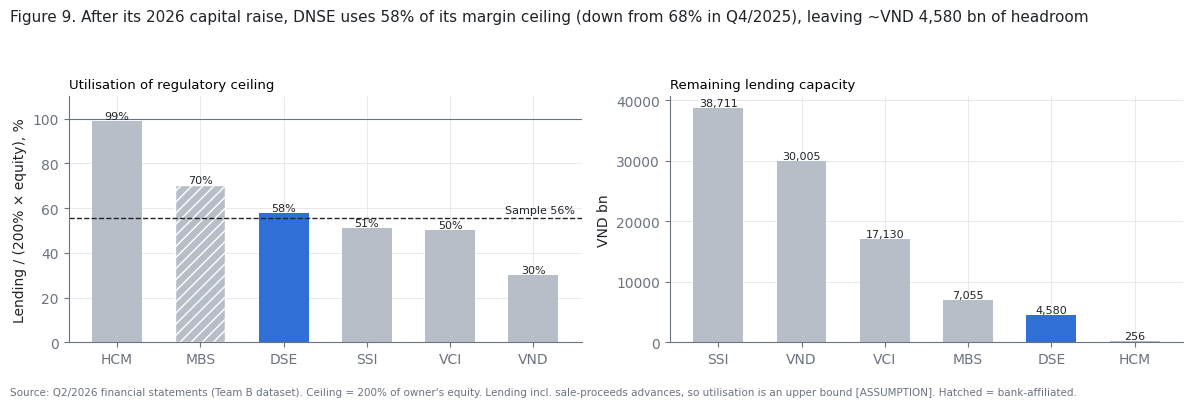

In [11]:
h = H2.drop(index="SAMPLE").sort_values("utilisation", ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
bars = axes[0].bar(h.index, h.utilisation * 100, color=bar_colors(h.index), width=0.6)
for bar, t in zip(bars, h.index):
    if bs.set_index("ticker").at[t, "bank_affiliated"]:
        bar.set_hatch("///"); bar.set_edgecolor("white")
axes[0].axhline(H2.at["SAMPLE", "utilisation"] * 100, color=INK, lw=1, ls="--")
axes[0].text(len(h) - 0.5, H2.at["SAMPLE", "utilisation"] * 100 + 2,
             f"Sample {H2.at['SAMPLE','utilisation']:.0%}", ha="right", fontsize=8, color=INK)
axes[0].axhline(100, color=MUTED, lw=0.8)
axes[0].set_ylabel("Lending / (200% × equity), %")
axes[0].set_ylim(0, 110)
axes[0].set_title("Utilisation of regulatory ceiling", fontsize=9.5, loc="left")
axes[0].bar_label(bars, labels=[f"{x:.0%}" for x in h.utilisation], fontsize=8, color=INK)

h2 = h.sort_values("headroom_bn", ascending=False)
bars = axes[1].bar(h2.index, h2.headroom_bn, color=bar_colors(h2.index), width=0.6)
axes[1].bar_label(bars, labels=[f"{x:,.0f}" for x in h2.headroom_bn], fontsize=8, color=INK)
axes[1].set_ylabel("VND bn")
axes[1].set_title("Remaining lending capacity", fontsize=9.5, loc="left")
fig.suptitle(f"Figure 9. After its 2026 capital raise, DNSE uses {H2.at['DSE','utilisation']:.0%} of its margin ceiling "
             f"(down from {H4.at['DSE','utilisation']:.0%} in Q4/2025), leaving ~VND {H2.at['DSE','headroom_bn']:,.0f} bn of headroom",
             x=0.01, ha="left", fontsize=11, color=INK)
footer(fig, "Source: Q2/2026 financial statements (Team B dataset). Ceiling = 200% of owner's equity. "
            "Lending incl. sale-proceeds advances, so utilisation is an upper bound [ASSUMPTION]. Hatched = bank-affiliated.")
fig.tight_layout(rect=(0, 0.05, 1, 0.92))
fig.savefig(FIG / "Fig09_B1_margin_headroom.png", dpi=200)
plt.show()

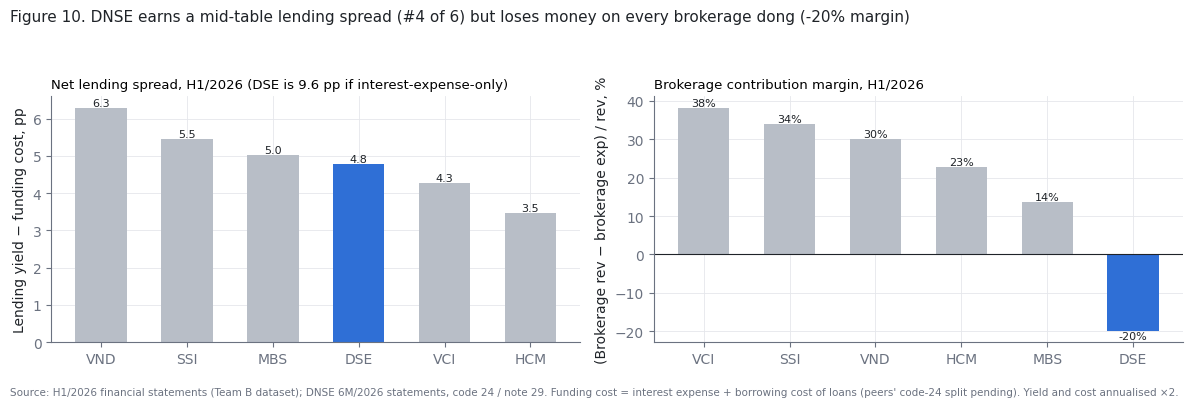

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
e = eff.sort_values("spread_A_pp", ascending=False)
bars = axes[0].bar(e.ticker, e.spread_A_pp, color=bar_colors(e.ticker), width=0.6)
axes[0].bar_label(bars, labels=[f"{x:.1f}" for x in e.spread_A_pp], fontsize=8, color=INK)
dse_B = eff.set_index("ticker").at["DSE", "spread_B_pp"]
axes[0].set_ylabel("Lending yield − funding cost, pp")
axes[0].set_title(f"Net lending spread, H1/2026 (DSE is {dse_B:.1f} pp if interest-expense-only)",
                  fontsize=9.5, loc="left")
e2 = eff.sort_values("contrib_margin_h1_26", ascending=False)
bars = axes[1].bar(e2.ticker, e2.contrib_margin_h1_26 * 100, color=bar_colors(e2.ticker), width=0.6)
axes[1].bar_label(bars, labels=[f"{x:.0%}" for x in e2.contrib_margin_h1_26], fontsize=8, color=INK)
axes[1].axhline(0, color=INK, lw=0.8)
axes[1].set_ylabel("(Brokerage rev − brokerage exp) / rev, %")
axes[1].set_title("Brokerage contribution margin, H1/2026", fontsize=9.5, loc="left")
ea = eff.set_index("ticker")
fig.suptitle(f"Figure 10. DNSE earns a mid-table lending spread (#{ea.at['DSE','rank_spread_A']} of 6) "
             f"but loses money on every brokerage dong ({ea.at['DSE','contrib_margin_h1_26']:.0%} margin)",
             x=0.01, ha="left", fontsize=11, color=INK)
footer(fig, "Source: H1/2026 financial statements (Team B dataset); DNSE 6M/2026 statements, code 24 / note 29. Funding cost = interest "
            "expense + borrowing cost of loans (peers' code-24 split pending). Yield and cost annualised ×2.")
fig.tight_layout(rect=(0, 0.05, 1, 0.92))
fig.savefig(FIG / "Fig10_B1_efficiency.png", dpi=200)
plt.show()

## 6. Table 4 – Axis-2 scores (quantitative rules, pending team approval)

Every cell is scored with **one rule applied identically to all three segments**. No cell is judgement-based except derivatives efficiency (see note).

| Measure | Indicator | 1–5 rule |
|---|---|---|
| 2.1 Momentum | Change in DSE's share over the **latest 12 months** (pp) | ≤ −5 → 1 · (−5, −1] → 2 · (−1, +1] → 3 · (+1, +5] → 4 · > +5 → 5 |
| 2.2 Headroom | **Growth still possible before a binding constraint** (g) | g < 10% → 1 · < 25% → 2 · < 50% → 3 · < 100% → 4 · ≥ 100% → 5 |
| 2.3 Efficiency | DSE's rank within the six-broker sample | Rank 1 → 5 · 2 → 4 · 3–4 → 3 · 5 → 2 · 6 → 1 |

Binding constraint used for g in each segment:
- **New investors:** stock-brokerage share catching up with account share.
- **Margin:** lending reaching the 200%-of-equity ceiling.
- **Derivatives:** derivatives share catching up with the leader, VPS.

**Derivatives efficiency:** no peer fee data, so no ranking is possible. Provisionally scored 2 [JUDGEMENT], based on estimated gross revenue of only VND 9–29 bn/yr despite a 25% share. A score of 3 is tested in the sensitivity check.

**2.4 and 2.5:** pending B2, left as `NaN`. Derivatives competition evidence is pre-computed in section 6.2.

In [13]:
SEGS = ["New investors", "Margin", "Derivatives"]

def score_change(pp):
    return 1 if pp <= -5 else 2 if pp <= -1 else 3 if pp <= 1 else 4 if pp <= 5 else 5

def score_room(g):
    return 1 if g < .10 else 2 if g < .25 else 3 if g < .50 else 4 if g < 1.0 else 5

def score_rank(r):
    return {1: 5, 2: 4, 3: 3, 4: 3, 5: 2, 6: 1}[int(r)]

ni = newinv
acc_share = ni["Total_Account_Share_2025"]
brk_share = ni["Total_Stock_Brokerage_Share_2025"]
vps_q2 = ds[(ds.quarter == "Q2/2026") & (ds.broker == "VPS")].share.iloc[0]
ROOM_DESC = {
    "New investors": "brokerage share catching up with account share",
    "Margin": "lending reaching the 200%-of-equity ceiling",
    "Derivatives": "derivatives share catching up with leader VPS",
}

def build_scores(mom, spread_rank_col="rank_spread_A", deriv_eff=2, brk=brk_share):
    room = {"New investors": acc_share / brk - 1,
            "Margin": H2.at["DSE", "headroom_vs_book"],
            "Derivatives": vps_q2 / dse_ds["Q2/2026"] - 1}
    rows = []
    for seg in SEGS:
        rows.append((seg, "2.1 Momentum", score_change(mom[seg]), f"DSE share {mom[seg]:+.2f} pp, last 12M"))
        rows.append((seg, "2.2 Headroom", score_room(room[seg]),
                     f"Room {room[seg]:.0%} before {ROOM_DESC[seg]}"))
    rows.append(("New investors", "2.3 Efficiency", score_rank(ea.at["DSE", "rank_contrib"]),
                 f"Brokerage contribution margin {ea.at['DSE','contrib_margin_h1_26']:.0%}, rank {ea.at['DSE','rank_contrib']}/6"))
    rows.append(("Margin", "2.3 Efficiency", score_rank(ea.at["DSE", spread_rank_col]),
                 f"Net lending spread {ea.at['DSE', spread_rank_col.replace('rank_', '') + '_pp']:.1f} pp, rank {ea.at['DSE', spread_rank_col]}/6"))
    rows.append(("Derivatives", "2.3 Efficiency", deriv_eff,
                 f"~VND {deriv_rev['rev_low_bn_per_year']:.0f}-{deriv_rev['rev_high_bn_per_year']:.0f} bn/yr gross at 25% share; no peer fee data [JUDGEMENT]"))
    for seg in SEGS:
        rows += [(seg, "2.4 Capability", np.nan, "Pending B2 (Table 3)"),
                 (seg, "2.5 Competition", np.nan, "Pending B2 (Figure 11)")]
    return pd.DataFrame(rows, columns=["segment", "measure", "score", "evidence"])

mom_base = momentum.set_index("segment").change_pp
scores = build_scores(mom_base)

bang4 = scores.pivot(index="segment", columns="measure", values="score").reindex(SEGS)
bang4["Axis 2 score (partial)"] = bang4.mean(axis=1, skipna=True)
bang4["n_measures"] = bang4.drop(columns="Axis 2 score (partial)").notna().sum(axis=1)
scores.to_csv(CLEAN / "Table4_axis2_evidence.csv", index=False)
bang4.to_csv(CLEAN / "Table4_axis2_scores_DRAFT.csv")
display(bang4.round(2))
with pd.option_context("display.max_colwidth", 120):
    display(scores[scores.score.notna()])

measure,2.1 Momentum,2.2 Headroom,2.3 Efficiency,2.4 Capability,2.5 Competition,Axis 2 score (partial),n_measures
segment,,,,,,,
New investors,2.0,5.0,1.0,NaN,NaN,2.67,3
Margin,3.0,4.0,3.0,NaN,NaN,3.33,3
Derivatives,5.0,3.0,2.0,NaN,NaN,3.33,3


,segment,measure,score,evidence
0,New investors,2.1 Momentum,2.0,"DSE share -1.07 pp, last 12M"
1,New investors,2.2 Headroom,5.0,Room 577% before brokerage share catching up with account share
2,Margin,2.1 Momentum,3.0,"DSE share -0.03 pp, last 12M"
3,Margin,2.2 Headroom,4.0,Room 73% before lending reaching the 200%-of-equity ceiling
4,Derivatives,2.1 Momentum,5.0,"DSE share +7.76 pp, last 12M"
5,Derivatives,2.2 Headroom,3.0,Room 33% before derivatives share catching up with leader VPS
6,New investors,2.3 Efficiency,1.0,"Brokerage contribution margin -20%, rank 6/6"
7,Margin,2.3 Efficiency,3.0,"Net lending spread 4.8 pp, rank 4/6"
8,Derivatives,2.3 Efficiency,2.0,~VND 9-29 bn/yr gross at 25% share; no peer fee data [JUDGEMENT]


### 6.1 Sensitivity check (axis-2 part of Table PL2)

In [14]:
def axis2(sc, drop=None):
    s = sc if drop is None else sc[sc.measure != drop]
    return s.groupby("segment").score.mean().reindex(SEGS)

def leaders(s):
    return " = ".join(s[np.isclose(s, s.max())].index)

mom_alt = mom_all[~mom_all.is_base].set_index("segment").change_pp
scen = {
    "Base": build_scores(mom_base),
    "Funding cost B (interest only)": build_scores(mom_base, "rank_spread_B"),
    "Alt momentum windows (18M / 6M / 6M)": build_scores(mom_alt),
    "Derivatives efficiency = 3": build_scores(mom_base, deriv_eff=3),
}
rows = {k: axis2(v) for k, v in scen.items()}
for m in ["2.1 Momentum", "2.2 Headroom", "2.3 Efficiency"]:
    rows[f"Drop {m}"] = axis2(scen["Base"], drop=m)
sens = pd.DataFrame(rows).T
sens["leader"] = sens[SEGS].apply(leaders, axis=1)
sens.to_csv(CLEAN / "Table_PL2_axis2_sensitivity.csv")
display(sens.round(2))
base_lead = sens.at["Base", "leader"]
print(f"Base leader: {base_lead}. Same leader in {(sens.leader == base_lead).sum()}/{len(sens)} scenarios.")

thr = pd.DataFrame([{"headroom score falls to": s, "if DSE stock-brokerage share exceeds": acc_share / (1 + g)}
                    for s, g in [(4, 1.0), (3, 0.5), (2, 0.25)]])
thr["if DSE stock-brokerage share exceeds"] = thr["if DSE stock-brokerage share exceeds"].map("{:.2%}".format)
display(thr)
print(f"Current value {brk_share:.2%} → the new-investor headroom score only changes if the true share is "
      f"above {acc_share/2:.1%}, i.e. {acc_share/2/brk_share:.1f}× the reported figure.")

segment,New investors,Margin,Derivatives,leader
Base,2.67,3.33,3.33,Margin = Derivatives
Funding cost B (interest only),2.67,4.00,3.33,Margin
Alt momentum windows (18M / 6M / 6M),2.33,3.33,3.00,Margin
Derivatives efficiency = 3,2.67,3.33,3.67,Derivatives
Drop 2.1 Momentum,3.00,3.50,2.50,Margin
Drop 2.2 Headroom,1.50,3.00,3.50,Derivatives
Drop 2.3 Efficiency,3.50,3.50,4.00,Derivatives


Base leader: Margin = Derivatives. Same leader in 1/7 scenarios.


,headroom score falls to,if DSE stock-brokerage share exceeds
0,4,6.50%
1,3,8.67%
2,2,10.40%


Current value 1.92% → the new-investor headroom score only changes if the true share is above 6.5%, i.e. 3.4× the reported figure.


### 6.2 Derivatives competition evidence (input to 2.5, not yet scored)

In [15]:
qorder = ["Q4/2024", "Q1/2025", "Q2/2025", "Q3/2025", "Q4/2025", "Q1/2026", "Q2/2026"]
conc = ds.groupby("quarter").apply(lambda d: pd.Series({
    "top2_share": d.nsmallest(2, "rank").share.sum(),
    "top5_share": d.nsmallest(5, "rank").share.sum(),
    "hhi_top10": ((d.share * 100) ** 2).sum(),
    "dse_rank": int(d.loc[d.broker == "DSE", "rank"].iloc[0]),
})).reindex(qorder)
conc.to_csv(CLEAN / "2.5_derivatives_concentration.csv")
display(conc.round(3))
print("HHI > 2,500 = highly concentrated (US DOJ convention); computed on top-10 shares only, so a lower bound.")

,top2_share,top5_share,hhi_top10,dse_rank
quarter,,,,
Q4/2024,0.658,0.818,3336.426,2.0
Q1/2025,0.674,0.833,2959.532,2.0
Q2/2025,0.640,0.809,2594.613,2.0
Q3/2025,0.598,0.784,2032.768,2.0
Q4/2025,0.581,0.795,1937.826,2.0
Q1/2026,0.588,0.800,1966.023,2.0
Q2/2026,0.592,0.815,2005.921,2.0


HHI > 2,500 = highly concentrated (US DOJ convention); computed on top-10 shares only, so a lower bound.


## 7. Report sentences and source register

Sentences are generated from the outputs above and saved to `report/findings_axis2_draft.md`.
- `[PENDING]` = waiting for B2's data.
- `[CHECK]` = waiting for BA confirmation.

In [16]:
e = ea
peer_med_yield = eff[eff.ticker != "DSE"].lending_yield.median()
mb = momentum.set_index("segment")
n_fixed = sum(1 for x in LOG)

lines = []
lines.append("# Team B – draft findings sentences (auto-generated from notebook/B1_axis2_supply_side.ipynb)\n")
lines.append("## Storyline beats 11–15 (section 5.4)\n")
lines.append("**Beat 11 – competition (Figure 11):** [PENDING B2] For derivatives only: the top two brokers held "
             f"{conc.at['Q2/2026','top2_share']:.0%} of the market in Q2/2026 (top five: {conc.at['Q2/2026','top5_share']:.0%}), "
             f"down from {conc.at['Q4/2024','top2_share']:.0%} in Q4/2024 as DNSE took share from the leader.\n")
lines.append(f"**Beat 12 – momentum (Figure 8):** \"Over the last 12 months DNSE's share rose from "
             f"{mb.at['Derivatives','start_val']:.1%} to {mb.at['Derivatives','end_val']:.1%} in derivatives brokerage, "
             f"was flat in margin lending ({mb.at['Margin','start_val']:.2%} → {mb.at['Margin','end_val']:.2%} of a six-broker sample) "
             f"and slipped in new-account acquisition ({mb.at['New investors','start_val']:.1%} → {mb.at['New investors','end_val']:.1%}).\"\n")
lines.append(f"**Beat 13 – headroom and efficiency (Figures 9, 10):** \"After its 2026 capital raise DNSE uses "
             f"{H2.at['DSE','utilisation']:.0%} of its margin ceiling (Q4/2025: {H4.at['DSE','utilisation']:.0%}), "
             f"leaving about VND {H2.at['DSE','headroom_bn']:,.0f} bn of headroom, and earns a "
             f"{e.at['DSE','lending_yield']:.1%} lending yield versus a peer median of {peer_med_yield:.1%}; "
             f"net of funding costs its spread of {e.at['DSE','spread_A_pp']:.1f} pp ranks #{e.at['DSE','rank_spread_A']} of 6 "
             f"[CHECK: peers' line-24 borrowing costs]. In brokerage, costs exceed revenue "
             f"(contribution margin {e.at['DSE','contrib_margin_h1_26']:.0%}, last of 6).\"\n")
lines.append("**Beat 14 – capability (Table 3):** [PENDING B2] \"DNSE matches peers on [ ] but lacks [ ] for [segment].\"\n")
b = bang4["Axis 2 score (partial)"]
top = [x.lower() for x in b[np.isclose(b, b.max())].index]
never_ni = int((~sens.leader.str.contains("New investors")).sum())
lines.append(f"**Beat 15 – axis-2 conclusion (Table 4):** \"On the three measures available, DNSE has the most room to grow in "
             + (" and ".join(top) + f" (tied at {b.max():.2f}" if len(top) > 1 else f"{top[0]} ({b.max():.2f}")
             + f"; new investors {b['New investors']:.2f}). New investors lead in none of the {len(sens)} sensitivity scenarios, "
             "so axis 2 rules them out; capability and competition [PENDING B2] will separate margin from derivatives.\"\n")
lines.append("## Section 5.1 – data (axis-2 part)\n")
lines.append(f"Axis 2 uses company-level data for a fixed sample of six listed brokers (DSE, SSI, VND, HCM, VCI, MBS) from Q4/2024 to Q2/2026, "
             "plus HNX derivatives brokerage shares and DNSE disclosures. Because DNSE reports margin loans and sale-proceeds advances as one "
             "figure, all lending metrics use loans plus advances for every broker. "
             f"All {val.match.sum()} spreadsheet calculations were re-computed in Python and matched; {n_fixed} data issues "
             "(date parsing, mixed definitions, unsourced cells) are logged in the appendix.\n")
lines.append("## Section 5.2 – method (axis-2 part)\n")
lines.append("Each client group is scored 1–5 on five supply-side measures with equal weights: momentum (12-month change in DNSE's share), "
             "headroom (growth still possible before a binding constraint), efficiency (DNSE's rank among six brokers), capability and "
             f"competition. Across {len(sens)} sensitivity scenarios (alternative funding-cost definition, time windows, and dropping each measure "
             f"in turn) the leader is always margin or derivatives; new investors never lead ({never_ni}/{len(sens)}).\n")
(ROOT / "report/findings_axis2_draft.md").write_text("\n".join(lines), encoding="utf-8")
print("\n".join(lines))

sources = pd.DataFrame([
    ("P1", "Vietstock 16/01/2026 – DNSE Q4/2025 results (loans + advances 5,832 bn)",
     "https://vietstock.vn/2026/01/dnse-dat-ky-luc-du-no-cho-vay-ky-quy-va-ung-truoc-tien-ban-737-1391525.htm", "2026-09-25", "VND bn", "C", "verified"),
    ("P2", "Vietstock 18/04/2026 – DNSE Q1/2026 results (loans + advances 5,910 bn)",
     "https://vietstock.vn/2026/04/dnse-noi-tiep-da-tang-truong-doanh-thu-va-du-no-margin-737-1429717.htm", "2026-09-25", "VND bn", "C", "verified"),
    ("P3", "Tin nhanh chứng khoán 21/07/2026 – DNSE Q2/2026 results (6,303 bn; H1 derivatives share 25.47%)",
     "https://www.tinnhanhchungkhoan.vn/du-no-cho-vay-ky-quy-va-ung-truoc-tien-ban-cua-dnse-dat-ky-luc-tren-6300-ty-dong-post394383.html", "2026-09-25", "VND bn", "C", "verified"),
    ("F1", "DNSE financial statements 6M/2026, income statement code 24 + note 29 (borrowing cost of loans 239.96 bn)",
     "https://ir.dnse.com.vn/vi/ctype-finance_report", "2026-09-25", "VND", "A", "verified by BA (check.pdf)"),
] + [(sid, "Team B dataset source ID – details pending", "", "", "", "", "PENDING BA")
     for sid in ["S5", "S6", "S7", "M1.1", "M1.2", "M2.1", "M2.2", "M3.1", "M3.2", "M4.1", "M4.2",
                 "D1", "D2", "D3", "D4", "D5", "D6", "D7", "A1", "A2"]],
    columns=["source_id", "description", "url", "accessed", "unit", "grade", "status"])
sources.to_csv(CLEAN / "B_sources.csv", index=False)
print(f"Sources table: {len(sources)} rows ({(sources.status != 'PENDING BA').sum()} verified, "
      f"{(sources.status == 'PENDING BA').sum()} pending BA)")

# Team B – draft findings sentences (auto-generated from notebook/B1_axis2_supply_side.ipynb)

## Storyline beats 11–15 (section 5.4)

**Beat 11 – competition (Figure 11):** [PENDING B2] For derivatives only: the top two brokers held 59% of the market in Q2/2026 (top five: 81%), down from 66% in Q4/2024 as DNSE took share from the leader.

**Beat 12 – momentum (Figure 8):** "Over the last 12 months DNSE's share rose from 17.6% to 25.4% in derivatives brokerage, was flat in margin lending (5.23% → 5.19% of a six-broker sample) and slipped in new-account acquisition (21.1% → 20.0%)."

**Beat 13 – headroom and efficiency (Figures 9, 10):** "After its 2026 capital raise DNSE uses 58% of its margin ceiling (Q4/2025: 68%), leaving about VND 4,580 bn of headroom, and earns a 11.1% lending yield versus a peer median of 10.8%; net of funding costs its spread of 4.8 pp ranks #4 of 6 [CHECK: peers' line-24 borrowing costs]. In brokerage, costs exceed revenue (contribution margin -20%, last of 6).

## 8. Hand-offs

- **8.1** Long-format dataset and data dictionary (for B2 and the Leader).
- **8.2** DNSE quarterly figures (for the Leader: Figures I2, I3 and Table PL1).

In [17]:
SRC_BA = "Team B dataset (BA) – source ID pending"
SRC_F1 = "DNSE FS 6M/2026, IS code 24 / note 29 (via BA)"
recs = []
def add(t, period, var, val, unit, src):
    recs.append(dict(ticker=t, period=period, variable=var, value=val, unit=unit, source=src))

for _, r in bs.iterrows():
    add(r.ticker, "Q4/2025", "equity", r.equity_q4_25, "VND bn", SRC_BA)
    add(r.ticker, "Q2/2026", "equity", r.equity_q2_26, "VND bn", SRC_BA)
    add(r.ticker, "Q4/2025", "financial_debt", r.debt_q4_25, "VND bn", SRC_BA)
    add(r.ticker, "Q2/2026", "financial_debt", r.debt_q2_26, "VND bn", SRC_BA)
    add(r.ticker, "Q2/2026", "cash", r.cash_q2_26, "VND bn", SRC_BA)
    add(r.ticker, "H1/2026", "interest_expense", r.int_exp_h1_26, "VND bn", SRC_BA)
    add(r.ticker, "static", "bank_affiliated", float(r.bank_affiliated), "0/1", SRC_BA)
for _, r in lend.iterrows():
    add(r.ticker, "Q4/2025", "lending_total", r.lending_q4_25, "VND bn", SRC_BA)
    add(r.ticker, "Q2/2026", "lending_total", r.lending_q2_26, "VND bn", SRC_BA)
    add(r.ticker, "H1/2026", "rev_lending", r.lending_income_h1_26, "VND bn", SRC_BA)
    add(r.ticker, "H1/2026", "borrow_cost_loans", r.other_borrow_cost_h1_26, "VND bn",
        SRC_F1 if r.ticker == "DSE" else "Not separated yet (set to 0) – R1")
for _, r in brk.iterrows():
    for per, rv, ex in [("H1/2025", r.brk_rev_h1_25, r.brk_exp_h1_25), ("H1/2026", r.brk_rev_h1_26, r.brk_exp_h1_26)]:
        add(r.ticker, per, "rev_brokerage", rv, "VND bn", SRC_BA)
        add(r.ticker, per, "exp_brokerage", ex, "VND bn", SRC_BA)
for _, r in mh.iterrows():
    add(r.ticker, r.quarter, "margin_reported", r.margin_bn, "VND bn", f"BA source {r.source_id}")

L_long = pd.DataFrame(recs)
L_long["in_fixed_sample"] = L_long.ticker.isin(TICKERS)
L_long.to_csv(CLEAN / "L_bctc_ctck_quarterly.csv", index=False)

dictionary = pd.DataFrame([
    ("equity", "Total owners' equity", "VND bn", "Quarter-end", "Balance sheet – owners' equity"),
    ("financial_debt", "Short- and long-term borrowings and finance leases + bonds issued", "VND bn", "Quarter-end", "Balance sheet"),
    ("cash", "Cash and cash equivalents", "VND bn", "Quarter-end", "Balance sheet"),
    ("interest_expense", "Interest expense (financial expenses line)", "VND bn", "6 months", "Income statement – financial expenses"),
    ("borrow_cost_loans", "Borrowing cost of loans = code 24 less loan-impairment provision", "VND bn", "6 months", "Income statement code 24 + provision note"),
    ("lending_total", "Total loans = margin loans + sale-proceeds advances (agreed definition, D01)", "VND bn", "Quarter-end", "Balance sheet – loans"),
    ("margin_reported", "Margin balance as recorded by the BA; definition differs across brokers (D01) – reference only", "VND bn", "Quarter-end", "Mixed"),
    ("rev_lending", "Interest from loans and receivables (incl. advances)", "VND bn", "6 months", "Income statement"),
    ("rev_brokerage", "Securities brokerage revenue", "VND bn", "6 months", "Income statement"),
    ("exp_brokerage", "Securities brokerage expense", "VND bn", "6 months", "Income statement"),
    ("bank_affiliated", "Parent company is a bank (1 = yes)", "0/1", "Static", "Company website"),
], columns=["variable", "definition", "unit", "period_type", "fs_line"])
dictionary.to_csv(CLEAN / "B_data_dictionary.csv", index=False)
print(f"L_bctc_ctck_quarterly.csv: {len(L_long)} rows, {L_long.variable.nunique()} variables, {L_long.ticker.nunique()} brokers")
display(dictionary)

L_bctc_ctck_quarterly.csv: 114 rows, 11 variables, 6 brokers


,variable,definition,unit,period_type,fs_line
0,equity,Total owners' equity,VND bn,Quarter-end,Balance sheet – owners' equity
1,financial_debt,Short- and long-term borrowings and finance le...,VND bn,Quarter-end,Balance sheet
2,cash,Cash and cash equivalents,VND bn,Quarter-end,Balance sheet
3,interest_expense,Interest expense (financial expenses line),VND bn,6 months,Income statement – financial expenses
4,borrow_cost_loans,Borrowing cost of loans = code 24 less loan-im...,VND bn,6 months,Income statement code 24 + provision note
5,lending_total,Total loans = margin loans + sale-proceeds adv...,VND bn,Quarter-end,Balance sheet – loans
6,margin_reported,Margin balance as recorded by the BA; definiti...,VND bn,Quarter-end,Mixed
7,rev_lending,Interest from loans and receivables (incl. adv...,VND bn,6 months,Income statement
8,rev_brokerage,Securities brokerage revenue,VND bn,6 months,Income statement
9,exp_brokerage,Securities brokerage expense,VND bn,6 months,Income statement


### 8.2 DNSE quarterly figures (for the Leader)

Quarterly figures come from press reports quoting the financial statements (grade C), plus code 24 from the 6M/2026 statements (grade A, provided by the BA).
- **Reconciliation:** Q1 + Q2 must equal the H1 figure in the BA dataset.
- **Brokerage expense Q2/2026** = H1 (dataset) − Q1 (press), labelled [ESTIMATE].

In [18]:
P1 = "Vietstock 16/01/2026"; P2 = "Vietstock 18/04/2026"; P3 = "Tin nhanh chứng khoán 21/07/2026"
q = pd.DataFrame([

    ("Q4/2025", "total_operating_revenue", 437.2, P1, ""),
    ("Q4/2025", "rev_brokerage", 125.0, P1, ""),
    ("Q4/2025", "exp_brokerage", 150.0, P1, "'nearly 150' – approximate"),
    ("Q4/2025", "rev_lending", 155.9, P1, ""),
    ("Q4/2025", "pbt", 11.7, P1, ""),
    ("Q4/2025", "lending_total", 5832.0, P1, "loans + advances"),
    ("Q1/2026", "total_operating_revenue", 395.0, P2, "'over 395'"),
    ("Q1/2026", "rev_brokerage", 119.5, P2, ""),
    ("Q1/2026", "exp_brokerage", 137.8, P2, ""),
    ("Q1/2026", "rev_lending", 147.5, P2, ""),
    ("Q1/2026", "pbt", 14.2, P2, "'nearly 14.2'"),
    ("Q1/2026", "lending_total", 5910.0, P2, "loans + advances"),
    ("Q1/2026", "borrow_cost_loans", 122.8 - 3.2, "BA (check.pdf)", "code 24 Q1 less provision"),
    ("Q2/2026", "total_operating_revenue", 453.1, P3, ""),
    ("Q2/2026", "rev_brokerage", 102.5, P3, ""),
    ("Q2/2026", "exp_brokerage", brk.set_index("ticker").at["DSE", "brk_exp_h1_26"] - 137.8, "Derived", "[ESTIMATE] H1 (BA) − Q1 (press)"),
    ("Q2/2026", "rev_lending", 188.6, P3, ""),
    ("Q2/2026", "pbt", 98.9, P3, ""),
    ("Q2/2026", "lending_total", 6303.0, P3, "loans + advances"),
    ("Q2/2026", "borrow_cost_loans", 126.1 - 5.7, "BA (check.pdf)", "code 24 Q2 less provision"),
    ("FY2025", "total_operating_revenue", 1467.0, P1, "'over 1,467'"),
    ("FY2025", "rev_brokerage", 404.0, P1, ""),
    ("FY2025", "rev_lending", 555.8, P1, ""),
    ("FY2025", "pbt", 340.2, P1, ""),
], columns=["period", "variable", "value_bn", "source", "note"])
q.to_csv(CLEAN / "DNSE_quarterly_for_Leader.csv", index=False)

wide = q.pivot_table(index="variable", columns="period", values="value_bn", aggfunc="first")
wide = wide[["Q4/2025", "Q1/2026", "Q2/2026", "FY2025"]]
wide["Q1+Q2 (2026)"] = wide["Q1/2026"] + wide["Q2/2026"]
display(wide.round(1))

Kd, Ld = brk.set_index("ticker").loc["DSE"], lend.set_index("ticker").loc["DSE"]
recon = pd.DataFrame([
    ("rev_brokerage H1/2026", wide.at["rev_brokerage", "Q1+Q2 (2026)"], Kd.brk_rev_h1_26),
    ("rev_lending H1/2026", wide.at["rev_lending", "Q1+Q2 (2026)"], Ld.lending_income_h1_26),
    ("borrow_cost_loans H1/2026", wide.at["borrow_cost_loans", "Q1+Q2 (2026)"], DSE_BORROW_COST_LOANS_6M26),
    ("pbt H1/2026 (press: 113.1)", wide.at["pbt", "Q1+Q2 (2026)"], 113.1),
    ("revenue H1/2026 (press: 848.2)", wide.at["total_operating_revenue", "Q1+Q2 (2026)"], 848.2),
], columns=["check", "sum_of_quarters", "reference"])
recon["diff"] = recon.sum_of_quarters - recon.reference
display(recon.round(2))

period,Q4/2025,Q1/2026,Q2/2026,FY2025,Q1+Q2 (2026)
variable,,,,,
borrow_cost_loans,NaN,119.6,120.4,NaN,240.0
exp_brokerage,150.0,137.8,128.7,NaN,266.5
lending_total,5832.0,5910.0,6303.0,NaN,12213.0
pbt,11.7,14.2,98.9,340.2,113.1
rev_brokerage,125.0,119.5,102.5,404.0,222.0
rev_lending,155.9,147.5,188.6,555.8,336.1
total_operating_revenue,437.2,395.0,453.1,1467.0,848.1


,check,sum_of_quarters,reference,diff
0,rev_brokerage H1/2026,222.0,222.10,-0.10
1,rev_lending H1/2026,336.1,336.10,0.00
2,borrow_cost_loans H1/2026,240.0,239.96,0.04
3,pbt H1/2026 (press: 113.1),113.1,113.10,0.00
4,revenue H1/2026 (press: 848.2),848.1,848.20,-0.10


## 9. Cleaning log

In [19]:
log_df = pd.DataFrame(LOG)
log_df.to_csv(CLEAN / "B_cleaning_log.csv", index=False)
display(log_df)

,code,sheet,cell,issue,action,before,after
0,D04,2.1_NewInvestors,H4,"Date parsed month-first, breaking chronologica...",Swap day and month back,2026-08-04,2026-04-08
1,D05,2.1_NewInvestors,"B2:B5,H2:H5",Dates stored as text,Parse with dayfirst=True,text,datetime
2,D06,2.1_NewInvestors,A5/E5,Label says FY/2025 but period column says Q4/2025,Treated as full-year 2025 (matches the Masterp...,Q4/2025,FY2025
3,D07,2.1_NewInvestors,L3,Source_ID holds a reporting period,"Source ID left blank, pending BA",Q4/2025,None
4,D11,2.3_Derivatives,C6,Text in a numeric column,Use 300 and flag negotiable,300 or upon agreement,300
5,D12,2.3_Derivatives,F4,Truncated label '[Asss',Renamed to side_factor [ASSUMPTION] = 2,Brokerage_Side_Factor [Asss,side_factor [ASSUMPTION]
6,D01,2.1_Margin / 2.3_Margin,DSE,"Reported 'margin' Q4/2025, Q2/2026 is actually...",Use total loans (2.3_Margin E/H) for all six b...,None,None
7,D01,2.1_Margin / 2.3_Margin,HCM,"Reported 'margin' Q4/2025, Q2/2026 is actually...",Use total loans (2.3_Margin E/H) for all six b...,None,None
8,D01,2.1_Margin / 2.3_Margin,VCI,Reported 'margin' Q4/2025 is actually total lo...,Use total loans (2.3_Margin E/H) for all six b...,None,None
9,D02,2.3_Margin,O2 (DSE),Hard-coded 240 bn borrowing cost; BA located t...,Use exact value = 248.926 - 8.964 bn,240.0,239.961
